In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from decimal import ROUND_HALF_UP, Decimal

In [4]:
df  = pd.read_csv('input\jpx-tokyo-stock-exchange-prediction\\training_price_features.csv')
df ['Date'] = pd.to_datetime(df ['Date'])
df = df[df['Date'] >= '2017-01-04']
df = df[df['Date'] <= '2017-02-15']

df.tail()


<>:1: SyntaxWarning: invalid escape sequence '\j'
<>:1: SyntaxWarning: invalid escape sequence '\j'
C:\Users\minghuiw\AppData\Local\Temp\3\ipykernel_14148\2055677158.py:1: SyntaxWarning: invalid escape sequence '\j'
  df  = pd.read_csv('input\jpx-tokyo-stock-exchange-prediction\\training_price_features.csv')


,RowId,Date,SecuritiesCode,Open,High,Low,Close,Volume,AdjustmentFactor,ExpectedDividend,...,ExpMovingAvg_20Day,Volatility_20Day,Return_30Day,MovingAvg_30Day,ExpMovingAvg_30Day,Volatility_30Day,Return_50Day,MovingAvg_50Day,ExpMovingAvg_50Day,Volatility_50Day
1879580,20170209_9997,2017-02-09,9997,834.0,835.0,819.0,830.0,161100,1.0,0,...,794.907760,0.023870,NaN,NaN,788.942594,NaN,NaN,NaN,784.269197,NaN
1879581,20170210_9997,2017-02-10,9997,830.0,833.0,817.0,826.0,182600,1.0,0,...,797.868926,0.023899,NaN,NaN,791.333394,NaN,NaN,NaN,785.905699,NaN
1879582,20170213_9997,2017-02-13,9997,832.0,837.0,823.0,831.0,168600,1.0,0,...,801.024266,0.023749,NaN,NaN,793.892530,NaN,NaN,NaN,787.674103,NaN
1879583,20170214_9997,2017-02-14,9997,833.0,860.0,833.0,840.0,180700,1.0,0,...,804.736241,0.023238,NaN,NaN,796.867206,NaN,NaN,NaN,789.726099,NaN
1879584,20170215_9997,2017-02-15,9997,842.0,857.0,837.0,856.0,116900,1.0,0,...,809.618504,0.023235,NaN,790.833333,800.682225,NaN,NaN,NaN,792.325075,NaN


### Add return_1day

In [5]:
df['return_1day'] = df['AdjustedClose'].pct_change(1)
df.head(5)

C:\Users\minghuiw\AppData\Local\Temp\3\ipykernel_14148\4234748944.py:1: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['return_1day'] = df['AdjustedClose'].pct_change(1)


,RowId,Date,SecuritiesCode,Open,High,Low,Close,Volume,AdjustmentFactor,ExpectedDividend,...,Volatility_20Day,Return_30Day,MovingAvg_30Day,ExpMovingAvg_30Day,Volatility_30Day,Return_50Day,MovingAvg_50Day,ExpMovingAvg_50Day,Volatility_50Day,return_1day
0,20170104_1301,2017-01-04,1301,2734.0,2755.0,2730.0,2742.0,31400,1.0,0,...,NaN,NaN,NaN,2742.000000,NaN,NaN,NaN,2742.000000,NaN,NaN
1,20170105_1301,2017-01-05,1301,2743.0,2747.0,2735.0,2738.0,17900,1.0,0,...,NaN,NaN,NaN,2741.741935,NaN,NaN,NaN,2741.843137,NaN,-0.001459
2,20170106_1301,2017-01-06,1301,2734.0,2744.0,2720.0,2740.0,19900,1.0,0,...,NaN,NaN,NaN,2741.629553,NaN,NaN,NaN,2741.770857,NaN,0.000730
3,20170110_1301,2017-01-10,1301,2745.0,2754.0,2735.0,2748.0,24200,1.0,0,...,NaN,NaN,NaN,2742.040549,NaN,NaN,NaN,2742.015137,NaN,0.002920
4,20170111_1301,2017-01-11,1301,2748.0,2752.0,2737.0,2745.0,9300,1.0,0,...,NaN,NaN,NaN,2742.231481,NaN,NaN,NaN,2742.132191,NaN,-0.001092


### Analyze Correlation

Correlation with Target:
SecuritiesCode               -0.011857
Open                         -0.015394
High                         -0.015437
Low                          -0.015620
Close                        -0.015618
Volume                       -0.012729
AdjustmentFactor              0.000174
ExpectedDividend             -0.009454
CumulativeAdjustmentFactor   -0.002948
AdjustedClose                -0.022036
Return_5Day                  -0.000833
MovingAvg_5Day               -0.020628
ExpMovingAvg_5Day            -0.021840
Volatility_5Day               0.019307
Return_10Day                  0.002715
MovingAvg_10Day              -0.022513
ExpMovingAvg_10Day           -0.021797
Volatility_10Day              0.047053
Return_20Day                  0.005234
MovingAvg_20Day              -0.020663
ExpMovingAvg_20Day           -0.021804
Volatility_20Day              0.028045
Return_30Day                       NaN
MovingAvg_30Day              -0.071650
ExpMovingAvg_30Day           -0.021803


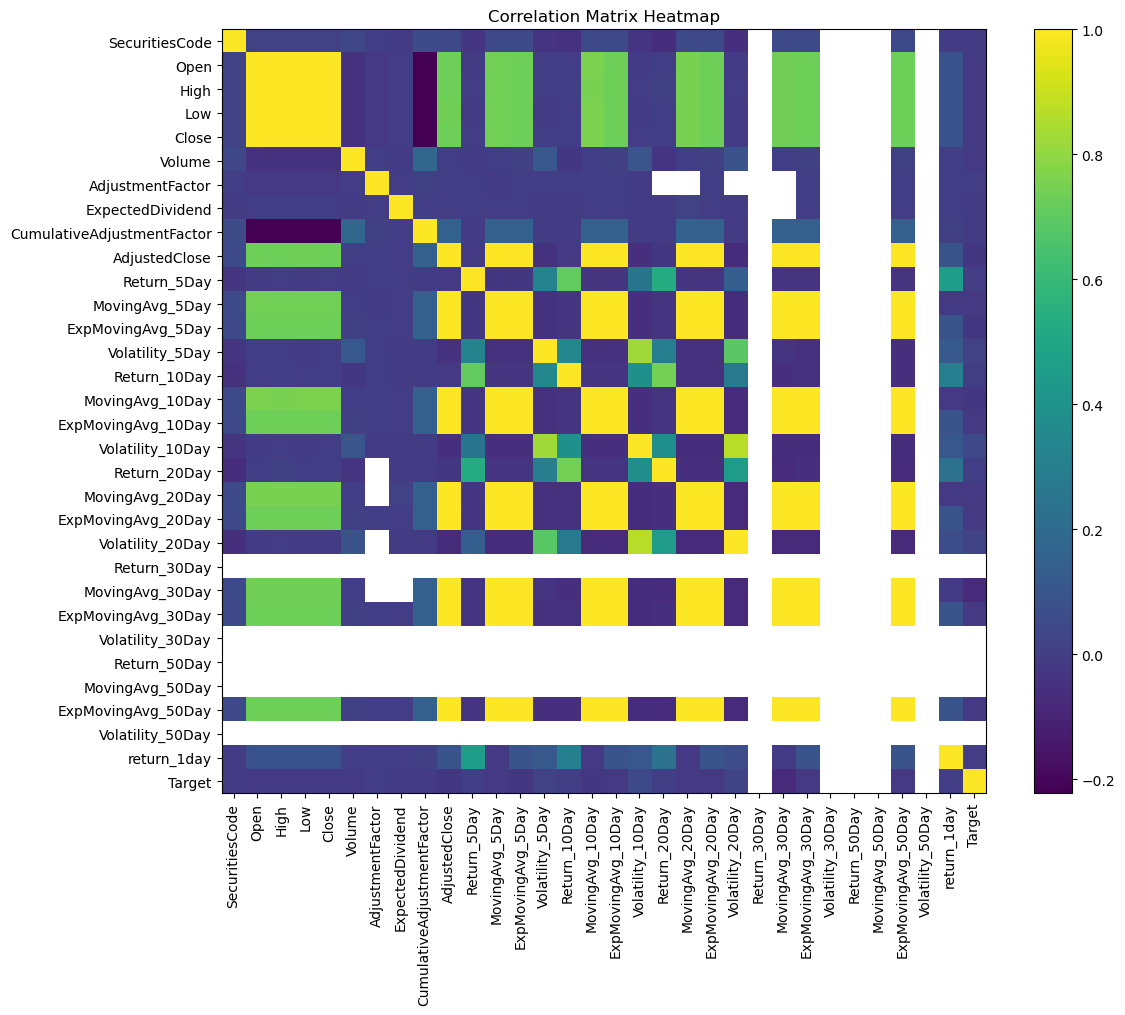

In [6]:
df_numeric = df.select_dtypes(include=['float64', 'int64'])

# Reorder the columns so that "Target" is at the very right (last column)
if "Target" in df_numeric.columns:
    cols = [col for col in df_numeric.columns if col != "Target"] + ["Target"]
    df_numeric = df_numeric[cols]
else:
    print("Warning: 'Target' column not found in numeric columns.")

# Calculate the correlation matrix for all numeric features
corr_matrix = df_numeric.corr()

# Print the correlation between each feature and the Target column
print("Correlation with Target:")
print(corr_matrix['Target'])

# ----------------------------------------
# 1. Visualize the full correlation matrix as a heatmap
# ----------------------------------------
plt.figure(figsize=(12, 10))
plt.imshow(corr_matrix, cmap='viridis', interpolation='none')
plt.colorbar()
plt.xticks(ticks=np.arange(len(corr_matrix.columns)), labels=corr_matrix.columns, rotation=90)
plt.yticks(ticks=np.arange(len(corr_matrix.index)), labels=corr_matrix.index)
plt.title("Correlation Matrix Heatmap")
plt.tight_layout()
plt.show()
